In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

from dotenv import load_dotenv
load_dotenv()

False

In [3]:
USE_S3 = os.getenv('USE_S3', 'false').lower() == 'true'
S3_BUCKET = os.getenv('S3_BUCKET', '')

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, '../data')

if USE_S3:
    df = pd.read_csv(f's3://{S3_BUCKET}/cleaned_data.csv')
else:
    df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))

print(f'Shape of the data : {df.shape}')
df.head()

Shape of the data : (13690540, 15)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0,0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0,0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0,0


In [ ]:
orders = df.groupby("order_id")["product_name"].apply(list)

pairs = []
for order in orders:
    pairs += list(combinations(order, 2))

pair_counts = Counter(pairs)

pair_df = pd.DataFrame(pair_counts.items(), columns=["product_pair", "count"])
pair_df = pair_df.sort_values(by="count", ascending=False)

top10 = pair_df.head(10)

labels = [f"{a} & {b}" for a, b in top10["product_pair"]]

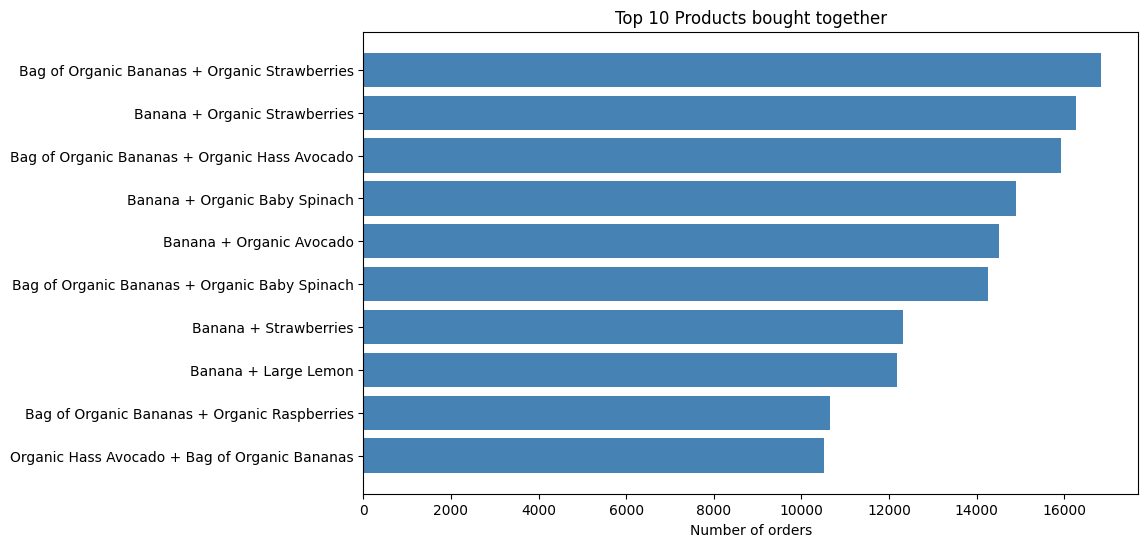

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(labels, top10["count"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Number of orders")
plt.title("Top 10 Products bought together")
plt.savefig(os.path.join(figures_dir, 'q5_produts_bought_together.png'), dpi=300, bbox_inches='tight')
plt.show()